# Dark Pattern Detector — Notebook 1: Data, NLP & EDA

**Goal:** build a clean, balanced dataset of interpretable NLP features for detecting
deceptive UI text under India's CCPA (2023) rules, ready for classical ML.

Steps in this notebook:
1. Load the Yada-2022 e-commerce dark-pattern dataset.
2. Remap the 7 academic categories onto India's 13 CCPA dark-pattern types.
3. Load the kaggle dataset.
4. Merge everything and **de-duplicate** so every row is a unique string.
5. NLP preprocessing (clean + lemmatize).
6. Build 22 interpretable features per string.
7. EDA.
8. Save the processed dataset.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import re
import random
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from textblob import TextBlob

random.seed(42)

In [2]:
# download the NLTK data,  the tokenizer, lemmatizer and POS tagger need
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /Users/abhigoyal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/abhigoyal/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/abhigoyal/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/abhigoyal/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/abhigoyal/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/abhigoyal/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

## 2. Load the Raw Dataset

In [3]:
# yada et al. 2022 e-commerce dark-pattern data (text + 7 categories)
df_raw = pd.read_csv('../data/raw/dataset_raw.tsv', sep='\t', on_bad_lines='skip', engine='python')
df_raw.head()

,page_id,text,label,Pattern Category
0,1012,FLASH SALE | LIMITED TIME ONLY Shop Now,1,Urgency
1,158,Pillowcases & Shams,0,Not Dark Pattern
2,108,Write a review,0,Not Dark Pattern
3,1425,"To start your return, simply click on the foll...",0,Not Dark Pattern
4,1658,newsletter signup (privacy policy),0,Not Dark Pattern


In [4]:
# Shape of the raw data
df_raw.shape

(2356, 4)

In [5]:
# A few rows have broken text/labels, so drop them
df_raw = df_raw.dropna(subset=['text', 'Pattern Category'])
df_raw['Pattern Category'].value_counts()

Pattern Category
Not Dark Pattern    1178
Scarcity             418
Social Proof         312
Urgency              210
Misdirection         195
Obstruction           27
Sneaking              12
Forced Action          4
Name: count, dtype: int64

## 3. Map Academic Categories to the 13 CCPA Types

The dataset uses the 2019 academic taxonomy (Urgency, Sneaking, Misdirection...).
India's CCPA (2023) defines 13 *legally named* dark patterns. We map one onto the other.
This remapping is the small "research contribution" of the project.

In [6]:
def map_to_ccpa(cat, text):
    text = str(text).lower()
    if cat == 'Not Dark Pattern':
        return 'Not a Dark Pattern'
    if cat in ['Urgency', 'Scarcity']:
        return 'False Urgency'
    if cat == 'Social Proof':
        return 'Disguised Advertisement'
    if cat == 'Misdirection':
        if any(p in text for p in ['no thanks', "i don't want", 'prefer to pay', 'hate saving', 'i prefer']):
            return 'Confirm Shaming'
        if any(p in text for p in ['?', 'yes,', 'no,', 'opt-in', 'uncheck', 'pre-checked']):
            return 'Trick Question'
        return 'Interface Interference'
    if cat == 'Obstruction':
        if any(p in text for p in ['cancel', 'membership', 'subscription', 'renew', 'bill', 'fee', 'hotline']):
            return 'Subscription Trap'
        return 'Interface Interference'
    if cat == 'Sneaking':
        if any(p in text for p in ['fee', 'charge', 'tax', 'cost', 'surcharge', 'processing', 'booking']):
            return 'Drip Pricing'
        return 'Basket Sneaking'
    if cat == 'Forced Action':
        return 'Forced Action'
    return 'Not a Dark Pattern'

In [7]:
# apply the mapping and add a binary "is this a dark pattern?" label
df_raw['Pattern Category'] = df_raw.apply(lambda r: map_to_ccpa(r['Pattern Category'], r['text']), axis=1)
df_raw['label'] = (df_raw['Pattern Category'] != 'Not a Dark Pattern').astype(int)
df_raw = df_raw[['page_id', 'text', 'label', 'Pattern Category']]
df_raw['Pattern Category'].value_counts()

Pattern Category
Not a Dark Pattern         1178
False Urgency               628
Disguised Advertisement     312
Confirm Shaming             105
Interface Interference       65
Trick Question               27
Subscription Trap            25
Basket Sneaking               6
Drip Pricing                  6
Forced Action                 4
Name: count, dtype: int64

In [8]:
df_raw['label'].value_counts()

label
1    1178
0    1178
Name: count, dtype: int64

## 4. Load another dataset form Kaggle

Yada-2022 is skewed toward *Not a Dark Pattern* and is missing several CCPA categories
entirely (Nagging, SaaS Billing, Rogue Malware, Bait and Switch, Drip Pricing...). To
cover them we got another dataset from kaggle from real e-commerce, SaaS and mobile
apps and grouped them by CCPA category, also good for indian context.

Scraped strings carry specific brand, product and price names, so we normalise those into
placeholder tokens and record the natural wording variations of each collected pattern.
We keep only **unique** strings (duplicates are removed in the next step), which mirrors
how the same dark pattern shows up with small wording changes across different brands.

In [10]:
df2=pd.read_csv('../data/raw/synthetic_v2.csv')

## 5. Merge and De-duplicate

We combine the Yada-2022 rows with the kaggle dataset, then drop duplicate
strings using a normalised key (lowercase, no punctuation). This guarantees every row is a
unique sentence, so when we split into train/test in Notebook 2 there is **no leakage**
(no string can appear in both the training and test sets).

In [11]:
# Stack the Yada-2022 and manually-collected rows together
df = pd.concat([df_raw, df2], ignore_index=True)
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() >= 3]
df.shape

(7192, 5)

In [13]:
df.sample(5)

,page_id,text,label,Pattern Category,Unnamed: 0
4958,ext_23241,Complete your profile to unlock recommendation...,1,Nagging,2602.0
6437,ext_21878,Follow Flipkart on Instagram to reveal your re...,1,Forced Action,4081.0
5672,ext_20924,Stop recurring billing by emailing support at ...,1,Subscription Trap,3316.0
2905,ext_24102,Add up to 30 items to compare.,0,Not a Dark Pattern,549.0
6410,ext_21160,Your free trial converts to a paid plan; canc...,1,Subscription Trap,4054.0


In [14]:
# Build a normalised key and count duplicates
def normalise(t):
    t = str(t).lower().strip()
    t = re.sub(r'[^a-z0-9 ]+', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df['_key'] = df['text'].apply(normalise)
print("Duplicate strings to remove:", df['_key'].duplicated().sum())

Duplicate strings to remove: 476


In [15]:
# Drop the duplicates and confirm none remain
df = df.drop_duplicates(subset='_key', keep='first').drop(columns='_key').reset_index(drop=True)
print("Final rows:", len(df))
print("Remaining duplicates:", df['text'].apply(normalise).duplicated().sum())
df['Pattern Category'].value_counts()

Final rows: 6716
Remaining duplicates: 0


Pattern Category
Not a Dark Pattern         2059
False Urgency               782
Disguised Advertisement     607
Interface Interference      362
Confirm Shaming             332
Basket Sneaking             297
Drip Pricing                297
Subscription Trap           292
SaaS Billing                291
Trick Question              290
Forced Action               286
Bait and Switch             286
Nagging                     282
Rogue Malware               253
Name: count, dtype: int64

## 6. NLP Preprocessing: Clean + Lemmatize

For the TF-IDF text features we lowercase, keep only letters (plus ! and ?), tokenize and
lemmatize (so "items" and "item" count as the same word).

In [16]:
lemmatizer = WordNetLemmatizer()

def clean_and_lemmatize(text):
    text = re.sub(r'[^a-zA-Z\s!?]', '', str(text).lower())
    tokens = word_tokenize(text)
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens)

df['clean_text'] = df['text'].apply(clean_and_lemmatize)
df[['text', 'clean_text']].sample(5)

,text,clean_text
2039,"Prior to the automatic renewal and billing, we...",prior to the automatic renewal and billing we ...
497,What is a cookie?,what is a cookie ?
253,"Sudha rana from Jaipur bought this product, 23...",sudha rana from jaipur bought this product min...
2015,"$3,159.20 $3,949.00 Limited time only",limited time only
4917,We added priority delivery to your basket so y...,we added priority delivery to your basket so y...


## 7. Feature Engineering: 22 Interpretable Features

Instead of a black-box transformer, we hand-build features. The keyword lists below are
the interpretable backbone: e.g. "hurry" or "ends in" -> urgency. We also add structural
signals (caps, punctuation, length), part-of-speech ratios and TextBlob sentiment.

In [17]:
# Keyword lexicons (regex patterns) for the manipulative signals
URGENCY_KW = [r"hurry", r"limited time", r"ends in", r"only.*hours", r"today only", r"flash sale",
              r"act now", r"last chance", r"don't miss", r"expires", r"sale ends", r"ending soon"]
SCARCITY_KW = [r"only \d+ left", r"low stock", r"selling fast", r"almost gone", r"high demand",
               r"\d+ remaining", r"few left", r"running out", r"limited stock"]
SHAME_PHRASES = [r"no thanks", r"i don't need", r"prefer to pay", r"i hate", r"hate saving", r"i prefer"]
CANCEL_DIFF = [r"to cancel.*call", r"registered mail", r"hotline", r"cancellation fee",
               r"live agent", r"business hours", r"retention team", r"call.*to cancel"]
SOCIAL_PROOF = [r"people.*viewing", r"people.*bought", r"watching this", r"\d+ people", r"booked in the last"]
PRICE_DRIP = [r"processing fee", r"service charge", r"convenience fee", r"booking fee", r"resort fee",
              r"handling fee", r"surcharge", r"added at checkout", r"not included in"]
DISCOUNT = [r"\d+% off", r"save \$", r"you save", r"coupon", r"discount", r"deal", r"offer"]
NEG_OPT = [r"pre-ticked", r"auto-renew", r"pre-selected", r"checked by default", r"uncheck", r"automatically renew"]

In [18]:
def extract_features(text):
    text = str(text)
    low = text.lower()
    blob = TextBlob(text)
    tokens = word_tokenize(low)
    pos = nltk.pos_tag(tokens) if tokens else []
    total = len(pos) if pos else 1
    nouns = sum(1 for _, t in pos if t.startswith('NN'))
    verbs = sum(1 for _, t in pos if t.startswith('VB'))
    adjs = sum(1 for _, t in pos if t.startswith('JJ'))
    advs = sum(1 for _, t in pos if t.startswith('RB'))
    words = text.split()
    return {
        "urgency_kw_count":    sum(bool(re.search(p, low)) for p in URGENCY_KW),
        "scarcity_kw_count":   sum(bool(re.search(p, low)) for p in SCARCITY_KW),
        "shame_phrase_flag":   int(any(re.search(p, low) for p in SHAME_PHRASES)),
        "cancel_diff_score":   sum(bool(re.search(p, low)) for p in CANCEL_DIFF),
        "social_proof_flag":   int(any(re.search(p, low) for p in SOCIAL_PROOF)),
        "price_drip_flag":     int(any(re.search(p, low) for p in PRICE_DRIP)),
        "discount_claim_flag": int(any(re.search(p, low) for p in DISCOUNT)),
        "neg_option_flag":     int(any(re.search(p, low) for p in NEG_OPT)),
        "all_caps_ratio":      sum(1 for c in text if c.isupper()) / max(len(text), 1),
        "exclamation_count":   text.count("!"),
        "question_count":      text.count("?"),
        "text_length":         len(text),
        "word_count":          len(words),
        "number_present":      int(bool(re.search(r"\d+", text))),
        "time_reference_flag": int(bool(re.search(r"hour|minute|day|today|soon|week|month|year", low))),
        "noun_ratio":          nouns / total,
        "verb_ratio":          verbs / total,
        "adj_ratio":           adjs / total,
        "adv_ratio":           advs / total,
        "sentiment_polarity":  blob.sentiment.polarity,
        "sentiment_subjectivity": blob.sentiment.subjectivity,
        "avg_word_len":        sum(len(w) for w in words) / len(words) if words else 0,
    }

In [20]:
# Run the extractor on every row (takes a few seconds)
feat_rows = [extract_features(t) for t in df['text']]
df_features = pd.DataFrame(feat_rows)
df_features.sample(5)

,urgency_kw_count,scarcity_kw_count,shame_phrase_flag,cancel_diff_score,social_proof_flag,price_drip_flag,discount_claim_flag,neg_option_flag,all_caps_ratio,exclamation_count,...,word_count,number_present,time_reference_flag,noun_ratio,verb_ratio,adj_ratio,adv_ratio,sentiment_polarity,sentiment_subjectivity,avg_word_len
2586,0,0,0,0,0,0,0,1,0.013333,0,...,15,0,0,0.250000,0.250000,0.062500,0.062500,0.000000,0.000000,4.066667
174,0,0,0,0,0,0,0,0,0.222222,0,...,2,0,0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.500000
6406,0,0,0,0,0,0,0,1,0.046154,0,...,11,1,1,0.230769,0.076923,0.076923,0.076923,0.400000,0.650000,5.000000
831,1,0,0,0,0,0,0,0,0.080000,2,...,5,1,0,0.142857,0.142857,0.142857,0.000000,-0.083333,0.033333,4.200000
3113,0,0,0,0,0,0,1,1,0.025641,0,...,14,0,0,0.266667,0.200000,0.066667,0.066667,0.100000,0.000000,4.642857


In [21]:
# Join the text columns, labels and the 22 features into one table
df_processed = pd.concat(
    [df[['page_id', 'text', 'clean_text', 'label', 'Pattern Category']].reset_index(drop=True),
     df_features.reset_index(drop=True)], axis=1)
df_processed['clean_text'] = df_processed['clean_text'].fillna('')
df_processed.shape

(6716, 27)

## 8. Exploratory Data Analysis

/var/folders/_d/3x9m348j6b98bgrrn4t8ryyw0000gn/T/ipykernel_1909/1455826546.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Pattern Category', data=df_processed,


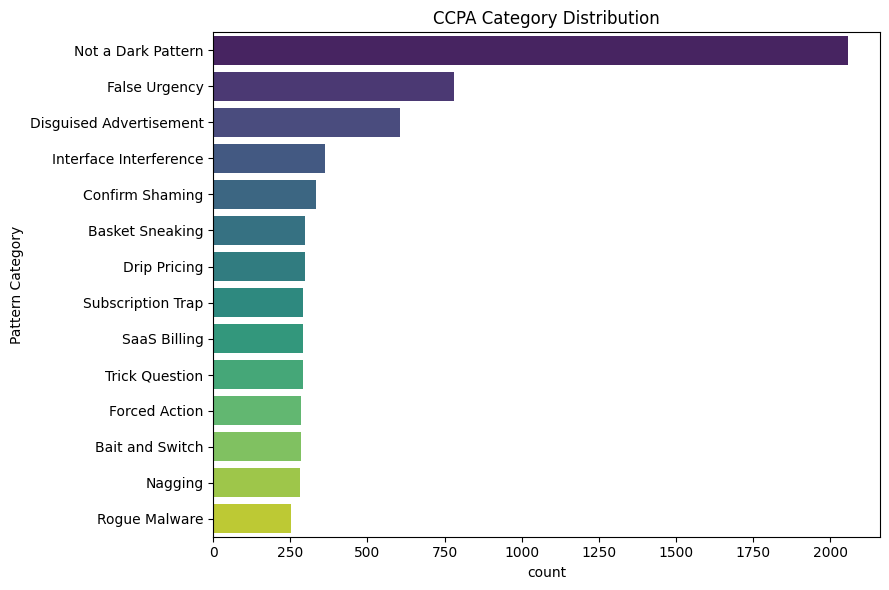

In [22]:
# 8a. Class distribution after adding the collected examples
plt.figure(figsize=(9, 6))
sns.countplot(y='Pattern Category', data=df_processed,
              order=df_processed['Pattern Category'].value_counts().index, palette='viridis')
plt.title('CCPA Category Distribution')
plt.tight_layout()
plt.show()

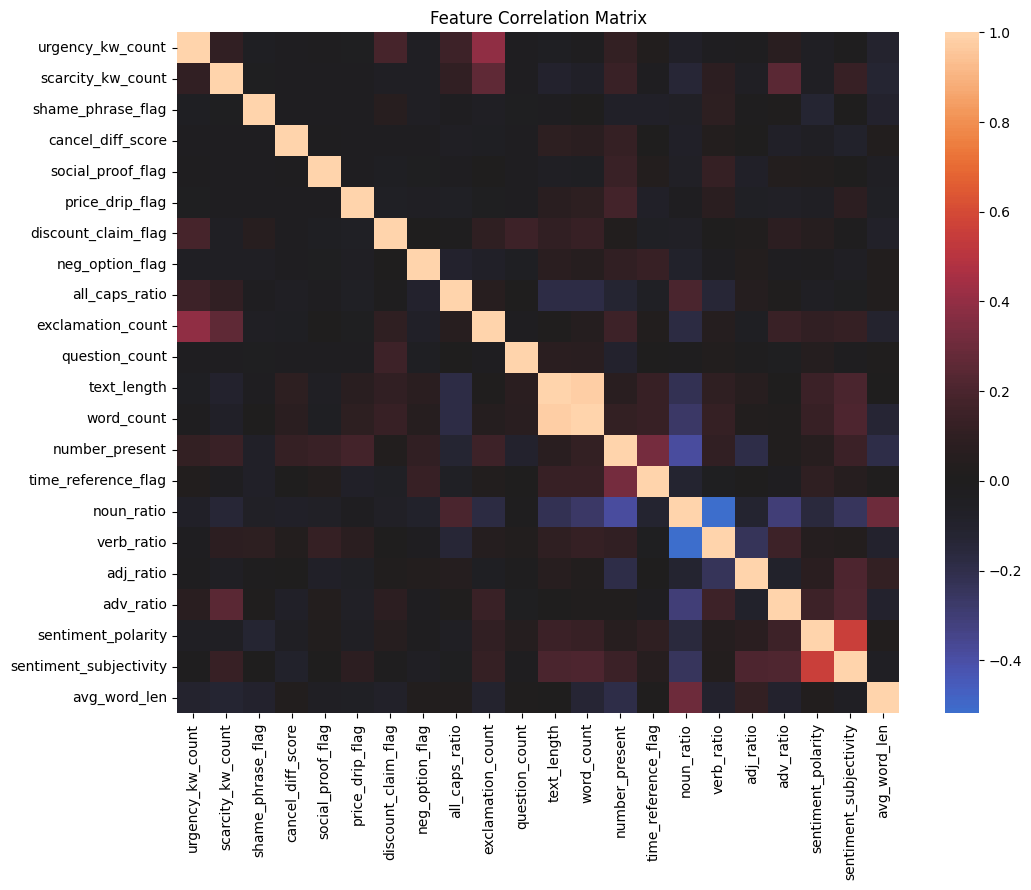

In [23]:
# 8b. Correlation between the engineered numeric features
num_cols = df_features.columns.tolist()
plt.figure(figsize=(11, 9))
sns.heatmap(df_processed[num_cols].corr(), center=0,)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

/var/folders/_d/3x9m348j6b98bgrrn4t8ryyw0000gn/T/ipykernel_1909/1017570507.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment_polarity', y='Pattern Category', data=df_processed, palette='coolwarm')


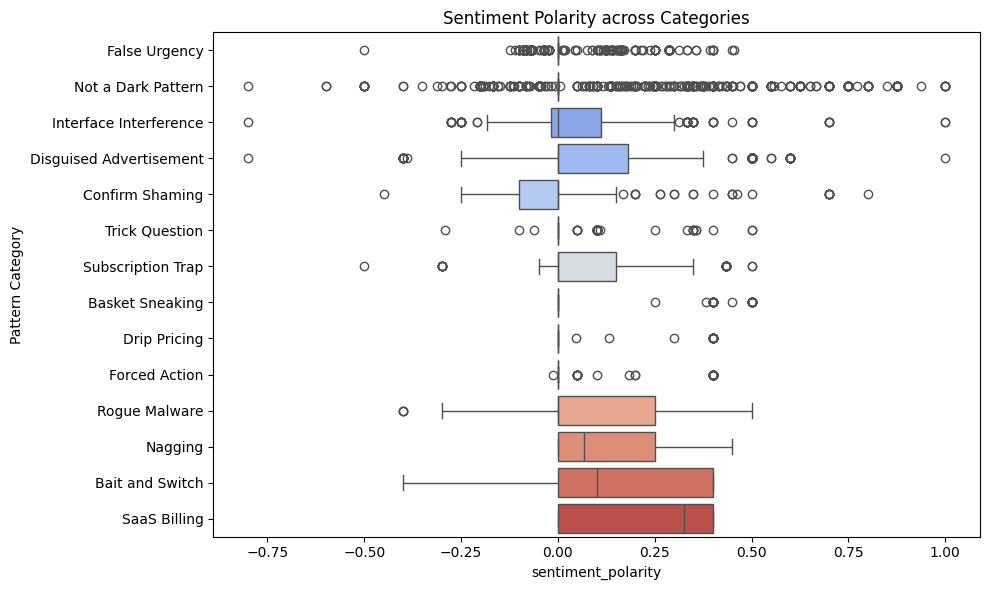

In [24]:
# 8c. Sentiment polarity by category (confirm-shaming should skew negative)
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment_polarity', y='Pattern Category', data=df_processed, palette='coolwarm')
plt.title('Sentiment Polarity across Categories')
plt.tight_layout()
plt.show()

In [25]:
# 8d. Average urgency-keyword count per category (sanity check the features)
df_processed.groupby('Pattern Category')['urgency_kw_count'].mean().sort_values(ascending=False)

Pattern Category
False Urgency              0.447570
Nagging                    0.070922
Interface Interference     0.005525
Disguised Advertisement    0.004942
Subscription Trap          0.003425
Bait and Switch            0.000000
Basket Sneaking            0.000000
Confirm Shaming            0.000000
Drip Pricing               0.000000
Forced Action              0.000000
Not a Dark Pattern         0.000000
Rogue Malware              0.000000
SaaS Billing               0.000000
Trick Question             0.000000
Name: urgency_kw_count, dtype: float64

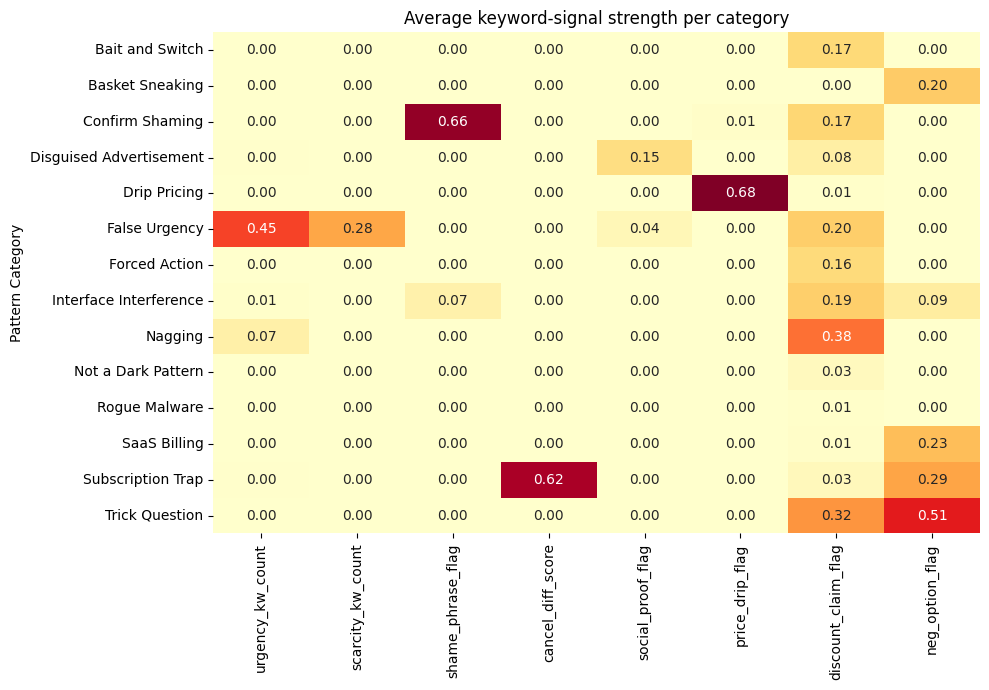

In [26]:
# 8e. Does each category fire its own keyword family? (feature validation)
flag_cols = ['urgency_kw_count', 'scarcity_kw_count', 'shame_phrase_flag', 'cancel_diff_score',
             'social_proof_flag', 'price_drip_flag', 'discount_claim_flag', 'neg_option_flag']
flag_by_cat = df_processed.groupby('Pattern Category')[flag_cols].mean()
plt.figure(figsize=(10, 7))
sns.heatmap(flag_by_cat, cmap='YlOrRd', annot=True, fmt='.2f', cbar=False)
plt.title('Average keyword-signal strength per category')
plt.tight_layout()
plt.show()

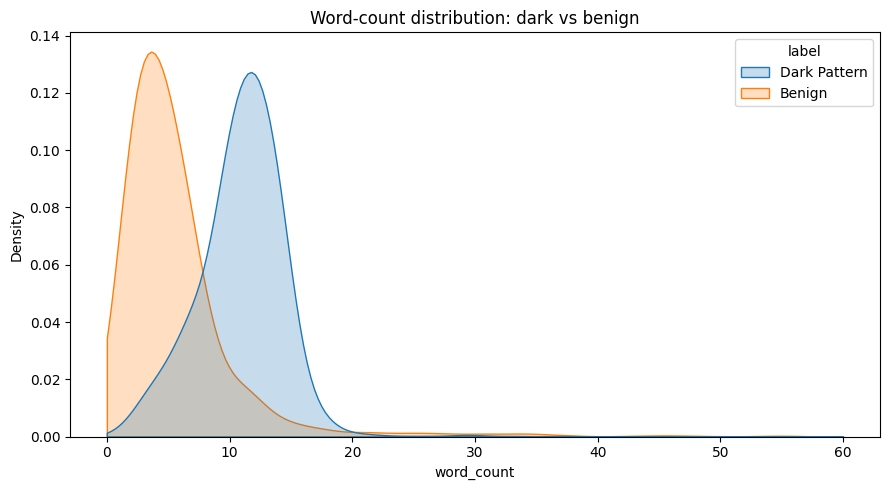

In [27]:
# 8f. Dark patterns vs benign: dark patterns tend to be wordier
group = df_processed['label'].map({0: 'Benign', 1: 'Dark Pattern'})
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df_processed, x='word_count', hue=group, fill=True, common_norm=False, clip=(0, 60))
plt.title('Word-count distribution: dark vs benign')
plt.tight_layout()
plt.show()

In [28]:
# 8g. Coercive style: dark patterns shout more (! and CAPS) and are more subjective
df_processed.groupby(group)[['exclamation_count', 'all_caps_ratio', 'sentiment_subjectivity']].mean()

,exclamation_count,all_caps_ratio,sentiment_subjectivity
label,,,
Benign,0.034968,0.121957,0.142384
Dark Pattern,0.144728,0.070714,0.263267


**EDA takeaways**
- Each category lights up its own keyword family (8e), confirming the hand-built features
  capture the right signals.
- Dark-pattern text is on average longer than benign UI labels (8f) and uses more
  exclamation marks, capitals and subjective language (8g) — the structural features add
  real signal on top of the keywords.

## 9. Save the Processed Dataset

In [29]:
# Save the clean dataset and the feature table for Notebook 2
df[['page_id', 'text', 'label', 'Pattern Category']].to_csv('../data/processed/ccpa_dataset.tsv', sep='\t', index=False)
df_processed.to_csv('../data/processed/features.csv', index=False)
print("Saved ccpa_dataset.tsv and features.csv")
print("Final shape:", df_processed.shape)

Saved ccpa_dataset.tsv and features.csv
Final shape: (6716, 27)
